# Stage 0 — COSMOS Manual Cutout Preparation with Stricter Screening

**Purpose:** build a cleaner real-galaxy source library from **manually downloaded** COSMOS HST/ACS F814W FITS cutouts, with a stronger post-download screening stage tailored to your GSoC Stage 0 goal.

This notebook is for the case where you already downloaded the FITS files yourself and now want:
- `.npy` export for later lenstronomy use,
- better metadata,
- stronger rejection of likely stars, bad crops, empty fields, diffraction-spike dominated images, and very compact point-like sources,
- a manual-review path before final acceptance.

## Scientific intent
Your GSoC proposal needs a **morphologically realistic source-galaxy library** for later lensing simulations. Since catalog-based cuts are not being applied inside this notebook, the screening here focuses on **image-level morphology heuristics** that are useful after manual download.

## What this notebook does
1. Reads manual FITS files from a folder.
2. Extracts RA/Dec from filename or WCS.
3. Computes screening features for each cutout.
4. Applies stricter heuristic flags for likely stars/artifacts.
5. Separates `accept`, `review`, and `reject` cases.
6. Saves only final accepted cutouts as `.npy`.
7. Writes metadata, screening tables, and diagnostic grids.

## Cell 1 — Install dependencies (run once)

In [ ]:
import subprocess
import sys

packages = [
    'numpy',
    'pandas',
    'matplotlib',
    'astropy',
    'tqdm',
    'scipy',
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('Dependencies installed successfully.')

## Cell 2 — Imports and configuration

Default pixel scale is set to **0.03 arcsec/pixel**, appropriate for the COSMOS ACS 30 mas mosaic products that match your current files.

In [1]:
import json
import math
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy import ndimage as ndi

from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales

warnings.filterwarnings('ignore')

RAW_DIR = Path('cosmos_cutouts/fits')
OUT_DIR = Path('cosmos_cutouts_manual_screened')
NPY_DIR = OUT_DIR / 'npy'
META_DIR = OUT_DIR / 'metadata'
PLOT_DIR = OUT_DIR / 'qa_plots'

for d in [RAW_DIR, OUT_DIR, NPY_DIR, META_DIR, PLOT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CUTOUT_SIZE_ARCSEC = 10.0
DEFAULT_PIXEL_SCALE_ARCSEC = 0.03
EXPECTED_SIZE_PIX = int(round(CUTOUT_SIZE_ARCSEC / DEFAULT_PIXEL_SCALE_ARCSEC))
MAX_FILES = None

# Manual overrides
FORCE_ACCEPT = set()
FORCE_REJECT = set()

# Thresholds for stricter screening
MIN_FINITE_FRACTION = 0.98
MIN_STD_NORM = 0.010
MAX_EDGE_ABS_MEAN = 0.45
MAX_PEAK_NORM = 4.5
MAX_PEAK_TO_P99 = 8.0
MIN_BRIGHT_AREA_FRAC = 0.0008
MAX_BRIGHT_AREA_FRAC = 0.35
MAX_COMPACTNESS = 0.16
MAX_CENTROID_OFFSET_FRAC = 0.30
MAX_SPIKE_RATIO = 5.0
MIN_CONNECTED_COMPONENT_AREA = 12

print(f'Input FITS folder   : {RAW_DIR.resolve()}')
print(f'Output folder       : {OUT_DIR.resolve()}')
print(f'Cutout size         : {CUTOUT_SIZE_ARCSEC:.1f}"')
print(f'Default pixel scale : {DEFAULT_PIXEL_SCALE_ARCSEC:.3f}"/pixel')
print(f'Expected size       : ~{EXPECTED_SIZE_PIX} px per side')

Input FITS folder   : C:\Users\upraj\Prajwal\GSOC\DeepLense\DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday\cosmos_cutouts\fits
Output folder       : C:\Users\upraj\Prajwal\GSOC\DeepLense\DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday\cosmos_cutouts_manual_screened
Cutout size         : 10.0"
Default pixel scale : 0.030"/pixel
Expected size       : ~333 px per side


## Cell 3 — Discover manual FITS files

In [2]:
fits_files = sorted(RAW_DIR.glob('*.fits')) + sorted(RAW_DIR.glob('*.fit'))
if MAX_FILES is not None:
    fits_files = fits_files[:MAX_FILES]

print(f'Found {len(fits_files)} FITS files.')
for fp in fits_files[:10]:
    print(' -', fp.name)

if len(fits_files) == 0:
    print('No FITS files found. Put your manually downloaded COSMOS cutouts into RAW_DIR and rerun.')

Found 50 FITS files.
 - 0001_150.329073_2.139497_acs_I_mosaic_30mas_sci.fits
 - 0002_150.054801_2.426702_acs_I_mosaic_30mas_sci.fits
 - 0003_150.218429_2.36785_acs_I_mosaic_30mas_sci.fits
 - 0004_150.293615_2.402216_acs_I_mosaic_30mas_sci.fits
 - 0005_150.300439_2.165881_acs_I_mosaic_30mas_sci.fits
 - 0006_149.7983_2.215854_acs_I_mosaic_30mas_sci.fits
 - 0007_149.825905_2.27702_acs_I_mosaic_30mas_sci.fits
 - 0008_150.110179_2.272575_acs_I_mosaic_30mas_sci.fits
 - 0009_150.028484_2.13021_acs_I_mosaic_30mas_sci.fits
 - 0010_150.186217_2.556423_acs_I_mosaic_30mas_sci.fits


## Cell 4 — Helper functions

The screening strategy here is intentionally more strict than the previous clean notebook.

### Main heuristics
- **finite fraction:** rejects broken arrays and NaN-heavy images,
- **edge signal:** rejects cutouts dominated by crop-edge flux,
- **peak-to-p99:** identifies very point-like or saturated sources,
- **bright-area fraction:** rejects almost-empty fields and also very overfilled frames,
- **compactness:** distinguishes broad galaxies from tiny point-like sources,
- **centroid offset:** flags off-centre objects or awkward crops,
- **spike ratio:** flags diffraction-spike-like patterns from bright stars.

In [3]:
COORD_PATTERN = re.compile(r'(?P<idx>?\d+)_(?P<ra>\d+\.\d+)_(?P<dec>[+-]?\d+\.\d+)_')

def parse_coords_from_filename(filename):
    m = COORD_PATTERN.search(filename)
    if m is None:
        return None, None
    return float(m.group('ra')), float(m.group('dec'))


def get_center_coords_from_wcs(header, shape):
    try:
        w = WCS(header)
        if not w.has_celestial:
            return None, None
        ny, nx = shape
        x_center = (nx - 1) / 2.0
        y_center = (ny - 1) / 2.0
        ra, dec = w.all_pix2world(x_center, y_center, 0)
        return float(ra), float(dec)
    except Exception:
        return None, None


def get_pixel_scale_arcsec(header):
    try:
        w = WCS(header)
        if not w.has_celestial:
            return DEFAULT_PIXEL_SCALE_ARCSEC
        scales = proj_plane_pixel_scales(w.celestial) * 3600.0
        scales = np.asarray(scales, dtype=float)
        if np.all(np.isfinite(scales)) and np.all(scales > 0):
            return float(np.mean(scales))
    except Exception:
        pass
    return DEFAULT_PIXEL_SCALE_ARCSEC


def robust_normalize(img):
    img = np.array(img, dtype=np.float32)
    finite = np.isfinite(img)
    finite_fraction = float(finite.mean())
    img = np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)

    sky_level = float(np.median(img))
    img_sub = img - sky_level
    p99_flux = float(np.percentile(img_sub, 99.0))
    scale = p99_flux if p99_flux > 0 else 1.0

    norm = (img_sub / scale).astype(np.float32)
    norm = np.clip(norm, -1.0, 5.0)
    return norm, sky_level, p99_flux, finite_fraction


def edge_abs_mean(arr):
    edge = np.concatenate([arr[0, :], arr[-1, :], arr[:, 0], arr[:, -1]])
    return float(np.mean(np.abs(edge)))


def radial_map(shape):
    ny, nx = shape
    y, x = np.indices(shape)
    cy = (ny - 1) / 2.0
    cx = (nx - 1) / 2.0
    r = np.sqrt((x - cx)**2 + (y - cy)**2)
    return r


def compute_screening_features(norm):
    pos = np.clip(norm, 0, None)
    total_pos = float(pos.sum())
    peak = float(norm.max())
    p99 = float(np.percentile(norm, 99.0))
    peak_to_p99 = peak / max(p99, 1e-6)
    std_norm = float(np.std(norm))
    edge_mean = edge_abs_mean(norm)

    bright_mask = norm > 0.20
    bright_area_frac = float(bright_mask.mean())

    # Flux-weighted centroid and compactness
    if total_pos > 0:
        y, x = np.indices(norm.shape)
        cy = float((y * pos).sum() / total_pos)
        cx = float((x * pos).sum() / total_pos)
    else:
        cy = (norm.shape[0] - 1) / 2.0
        cx = (norm.shape[1] - 1) / 2.0

    cy0 = (norm.shape[0] - 1) / 2.0
    cx0 = (norm.shape[1] - 1) / 2.0
    centroid_offset_pix = float(np.sqrt((cy - cy0)**2 + (cx - cx0)**2))
    centroid_offset_frac = centroid_offset_pix / max(norm.shape)

    rr = radial_map(norm.shape)
    if total_pos > 0:
        compact_flux = float(pos[rr <= 4.0].sum()) / total_pos
    else:
        compact_flux = 0.0

    # Connected bright components
    structure = np.ones((3, 3), dtype=int)
    labeled, nlab = ndi.label(bright_mask, structure=structure)
    if nlab > 0:
        areas = ndi.sum(bright_mask, labeled, index=np.arange(1, nlab + 1))
        areas = np.asarray(areas, dtype=float)
        max_component_area = float(areas.max())
        n_components = int(np.sum(areas >= MIN_CONNECTED_COMPONENT_AREA))
    else:
        max_component_area = 0.0
        n_components = 0

    # Diffraction-spike proxy: central row/column dominance vs diagonals
    midy = norm.shape[0] // 2
    midx = norm.shape[1] // 2
    center_strip = 8
    row_band = np.clip(pos[max(0, midy-center_strip):min(norm.shape[0], midy+center_strip+1), :], 0, None)
    col_band = np.clip(pos[:, max(0, midx-center_strip):min(norm.shape[1], midx+center_strip+1)], 0, None)

    diag1 = np.clip(np.diag(pos), 0, None)
    diag2 = np.clip(np.diag(np.fliplr(pos)), 0, None)
    cross_flux = float(row_band.sum() + col_band.sum())
    diag_flux = float(diag1.sum() + diag2.sum()) + 1e-6
    spike_ratio = cross_flux / diag_flux

    return {
        'std_norm': std_norm,
        'peak_norm': peak,
        'peak_to_p99': peak_to_p99,
        'edge_abs_mean': edge_mean,
        'bright_area_frac': bright_area_frac,
        'compactness': compact_flux,
        'centroid_offset_frac': centroid_offset_frac,
        'max_component_area': max_component_area,
        'n_bright_components': n_components,
        'spike_ratio': float(spike_ratio),
    }


def classify_cutout(features, finite_fraction, filename):
    reasons_reject = []
    reasons_review = []

    if filename in FORCE_REJECT:
        return 'reject', ['force_reject']
    if filename in FORCE_ACCEPT:
        return 'accept', ['force_accept']

    if finite_fraction < MIN_FINITE_FRACTION:
        reasons_reject.append('too_many_nonfinite_pixels')
    if features['std_norm'] < MIN_STD_NORM:
        reasons_reject.append('near_empty_or_too_flat')
    if features['edge_abs_mean'] > MAX_EDGE_ABS_MEAN:
        reasons_reject.append('strong_edge_signal_bad_crop')
    if features['bright_area_frac'] < MIN_BRIGHT_AREA_FRAC:
        reasons_reject.append('too_little_bright_structure')
    if features['bright_area_frac'] > MAX_BRIGHT_AREA_FRAC:
        reasons_reject.append('too_much_bright_area')

    if features['peak_norm'] > MAX_PEAK_NORM:
        reasons_review.append('very_high_peak')
    if features['peak_to_p99'] > MAX_PEAK_TO_P99:
        reasons_review.append('point_like_peak')
    if features['compactness'] > MAX_COMPACTNESS:
        reasons_review.append('too_compact_possible_star')
    if features['centroid_offset_frac'] > MAX_CENTROID_OFFSET_FRAC:
        reasons_review.append('off_center_source')
    if features['spike_ratio'] > MAX_SPIKE_RATIO:
        reasons_review.append('possible_diffraction_spike')
    if features['max_component_area'] < MIN_CONNECTED_COMPONENT_AREA:
        reasons_review.append('tiny_connected_structure')

    if reasons_reject:
        return 'reject', reasons_reject
    if reasons_review:
        return 'review', reasons_review
    return 'accept', ['passed_strict_screening']

## Cell 5 — Read FITS files and compute screening features

In [4]:
manifest = []
image_store = {}

for fp in tqdm(fits_files, desc='Reading and screening FITS'):
    try:
        with fits.open(fp, memmap=False) as hdul:
            data = hdul[0].data
            header = hdul[0].header

        if data is None:
            manifest.append({'filename': fp.name, 'status': 'reject', 'reason': 'empty_primary_hdu'})
            continue

        data = np.squeeze(np.array(data))
        if data.ndim != 2:
            manifest.append({'filename': fp.name, 'status': 'reject', 'reason': f'non_2d_shape_{data.shape}'})
            continue

        ra, dec = parse_coords_from_filename(fp.name)
        if ra is None or dec is None:
            ra, dec = get_center_coords_from_wcs(header, data.shape)

        pixel_scale = get_pixel_scale_arcsec(header)
        norm, sky_level, p99_flux, finite_fraction = robust_normalize(data)
        features = compute_screening_features(norm)
        status, reasons = classify_cutout(features, finite_fraction, fp.name)

        record = {
            'filename': fp.name,
            'path': str(fp),
            'ra': None if ra is None else float(ra),
            'dec': None if dec is None else float(dec),
            'shape_y': int(data.shape[0]),
            'shape_x': int(data.shape[1]),
            'pixel_scale_arcsec': float(pixel_scale),
            'cutout_size_arcsec_y': float(data.shape[0] * pixel_scale),
            'cutout_size_arcsec_x': float(data.shape[1] * pixel_scale),
            'sky_level': float(sky_level),
            'p99_flux': float(p99_flux),
            'finite_fraction': float(finite_fraction),
            'status': status,
            'reason': ';'.join(reasons),
            **features,
        }
        manifest.append(record)
        image_store[fp.name] = norm

    except Exception as e:
        manifest.append({'filename': fp.name, 'status': 'reject', 'reason': f'exception: {type(e).__name__}: {e}'})

manifest_df = pd.DataFrame(manifest)
manifest_df.head()

Reading and screening FITS:   0%|          | 0/50 [00:00<?, ?it/s]

,filename,path,ra,dec,shape_y,shape_x,pixel_scale_arcsec,cutout_size_arcsec_y,cutout_size_arcsec_x,sky_level,...,std_norm,peak_norm,peak_to_p99,edge_abs_mean,bright_area_frac,compactness,centroid_offset_frac,max_component_area,n_bright_components,spike_ratio
0,0001_150.329073_2.139497_acs_I_mosaic_30mas_sc...,cosmos_cutouts\fits\0001_150.329073_2.139497_a...,150.329073,2.139497,335,335,0.03,10.05,10.05,0.002171,...,0.198965,3.682375,3.682375,0.012155,0.076436,0.020299,0.002080,8558.0,1,26.912173
1,0002_150.054801_2.426702_acs_I_mosaic_30mas_sc...,cosmos_cutouts\fits\0002_150.054801_2.426702_a...,150.054801,2.426702,335,335,0.03,10.05,10.05,0.000263,...,0.269309,5.000000,5.000000,0.039929,0.038922,0.039681,0.000221,4230.0,2,21.358325
2,0003_150.218429_2.36785_acs_I_mosaic_30mas_sci...,cosmos_cutouts\fits\0003_150.218429_2.36785_ac...,150.218429,2.367850,335,335,0.03,10.05,10.05,0.000665,...,0.220403,5.000000,5.000000,0.012844,0.034493,0.049778,0.006429,3784.0,3,21.404371
3,0004_150.293615_2.402216_acs_I_mosaic_30mas_sc...,cosmos_cutouts\fits\0004_150.293615_2.402216_a...,150.293615,2.402216,335,335,0.03,10.05,10.05,0.000153,...,0.272316,5.000000,5.000000,0.098457,0.086959,0.027302,0.034211,2990.0,28,19.530582
4,0005_150.300439_2.165881_acs_I_mosaic_30mas_sc...,cosmos_cutouts\fits\0005_150.300439_2.165881_a...,150.300439,2.165881,335,335,0.03,10.05,10.05,0.000246,...,0.325953,5.000000,5.000000,0.155527,0.165427,0.016965,0.016276,4382.0,142,19.974466


## Cell 6 — Screening summary

This notebook uses three output classes:
- `accept`: safe enough to keep automatically,
- `review`: suspicious, inspect visually before deciding,
- `reject`: strong evidence of bad input, empty field, or obviously poor cutout.

In [6]:
print('Total files :', len(manifest_df))
print('Accept      :', int((manifest_df['status'] == 'accept').sum()))
print('Review      :', int((manifest_df['status'] == 'review').sum()))
print('Reject      :', int((manifest_df['status'] == 'reject').sum()))

print('Top reasons:')
print(manifest_df['reason'].value_counts(dropna=False).head(25))

accepted_df = manifest_df[manifest_df['status'] == 'accept'].copy().reset_index(drop=True)
review_df = manifest_df[manifest_df['status'] == 'review'].copy().reset_index(drop=True)
rejected_df = manifest_df[manifest_df['status'] == 'reject'].copy().reset_index(drop=True)

accepted_df.head()

Total files : 50
Accept      : 0
Review      : 50
Reject      : 0
Top reasons:
reason
very_high_peak;possible_diffraction_spike                      37
possible_diffraction_spike                                     11
very_high_peak                                                  1
very_high_peak;off_center_source;possible_diffraction_spike     1
Name: count, dtype: int64


,filename,path,ra,dec,shape_y,shape_x,pixel_scale_arcsec,cutout_size_arcsec_y,cutout_size_arcsec_x,sky_level,...,std_norm,peak_norm,peak_to_p99,edge_abs_mean,bright_area_frac,compactness,centroid_offset_frac,max_component_area,n_bright_components,spike_ratio


## Cell 7 — Inspect screening features numerically

In [7]:
feature_cols = [
    'std_norm', 'peak_norm', 'peak_to_p99', 'edge_abs_mean',
    'bright_area_frac', 'compactness', 'centroid_offset_frac',
    'max_component_area', 'n_bright_components', 'spike_ratio'
]

if len(manifest_df) > 0:
    display(manifest_df.groupby('status')[feature_cols].describe().round(4))
else:
    print('No files available.')

std_norm                                                        \
          count   mean     std    min     25%     50%     75%     max   
status                                                                  
review     50.0  0.351  0.0613  0.199  0.3115  0.3784  0.3999  0.4191   

       peak_norm          ... n_bright_components        spike_ratio          \
           count    mean  ...                 75%    max       count    mean   
status                    ...                                                  
review      50.0  4.7025  ...               669.5  721.0        50.0  18.553   

                                                            
           std     min      25%      50%      75%      max  
status                                                      
review  5.6995  1.9655  15.7006  18.5221  19.9381  39.9468  

[1 rows x 80 columns]

## Cell 8 — Visual grids: accepted, review, rejected

These grids are the most important part of the stricter workflow. The `review` grid is where you decide whether suspicious cutouts are still scientifically useful as source galaxies.

No accept cutouts to plot.


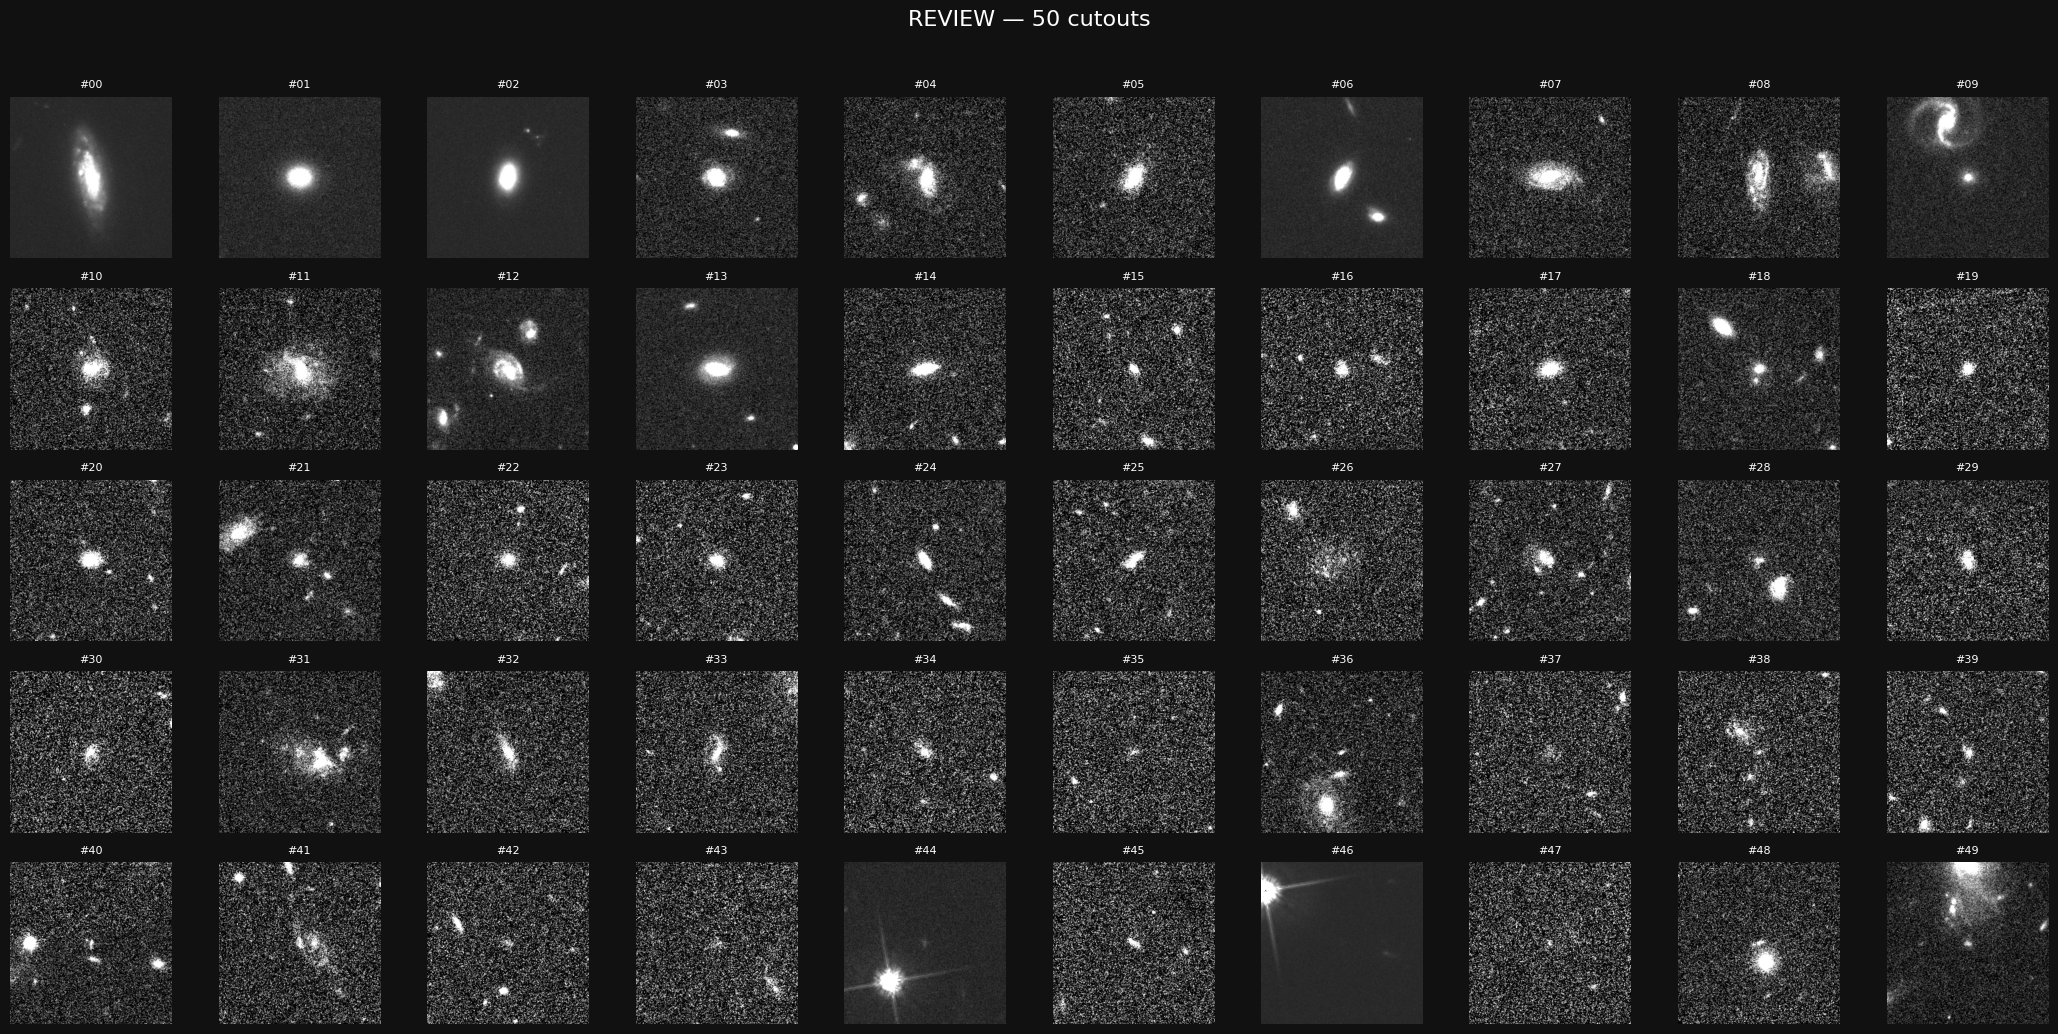

Saved: C:\Users\upraj\Prajwal\GSOC\DeepLense\DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday\cosmos_cutouts_manual_screened\qa_plots\grid_review.jpg
No reject cutouts to plot.


In [8]:
def save_status_grid(df, status_name, max_show=50, vmin=-0.2, vmax=1.0):
    names = df['filename'].tolist()[:max_show]
    if len(names) == 0:
        print(f'No {status_name} cutouts to plot.')
        return None

    ncols = 10
    nrows = math.ceil(len(names) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.1 * ncols, 2.1 * nrows), facecolor='#111111')
    axes = np.array(axes).reshape(nrows, ncols)

    for ax in axes.ravel():
        ax.set_facecolor('#111111')
        ax.axis('off')

    for i, name in enumerate(names):
        ax = axes.ravel()[i]
        ax.imshow(image_store[name], cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
        ax.set_title(f'#{i:02d}', color='white', fontsize=8)
        ax.axis('off')

    fig.suptitle(f'{status_name.upper()} — {len(names)} cutouts', color='white', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    out_path = PLOT_DIR / f'grid_{status_name}.jpg'
    fig.savefig(out_path, dpi=180, facecolor=fig.get_facecolor(), bbox_inches='tight')
    plt.show()
    print('Saved:', out_path.resolve())
    return out_path

save_status_grid(accepted_df, 'accept')
save_status_grid(review_df, 'review')
save_status_grid(rejected_df, 'reject')

## Cell 9 — Manual decision step for `review` cutouts

Add filenames to `FORCE_ACCEPT` or `FORCE_REJECT`, then rerun **Cell 5 onward**.

In [ ]:
# Example:
# FORCE_ACCEPT = {
#     '0017_150.375938_2.243623_acs_I_mosaic_30mas_sci.fits',
# }
# FORCE_REJECT = {
#     '0047_150.062815_2.100594_acs_I_mosaic_30mas_sci.fits',
# }
print('FORCE_ACCEPT:', len(FORCE_ACCEPT))
print('FORCE_REJECT:', len(FORCE_REJECT))

## Cell 10 — Final export of accepted cutouts only

This writes only the final `accept` set to `.npy` and saves full metadata/screening tables.

In [ ]:
for old_file in NPY_DIR.glob('*.npy'):
    old_file.unlink()

metadata = []

for _, row in accepted_df.iterrows():
    filename = row['filename']
    arr = image_store[filename]
    stem = Path(filename).stem
    npy_name = f'{stem}.npy'
    np.save(NPY_DIR / npy_name, arr)

    metadata.append({
        'filename': filename,
        'npy_name': npy_name,
        'ra': None if pd.isna(row.get('ra')) else float(row['ra']),
        'dec': None if pd.isna(row.get('dec')) else float(row['dec']),
        'shape': [int(arr.shape[0]), int(arr.shape[1])],
        'pixel_scale_arcsec': None if pd.isna(row.get('pixel_scale_arcsec')) else float(row['pixel_scale_arcsec']),
        'cutout_size_arcsec': CUTOUT_SIZE_ARCSEC,
        'sky_level': None if pd.isna(row.get('sky_level')) else float(row['sky_level']),
        'p99_flux': None if pd.isna(row.get('p99_flux')) else float(row['p99_flux']),
        'finite_fraction': None if pd.isna(row.get('finite_fraction')) else float(row['finite_fraction']),
        'std_norm': None if pd.isna(row.get('std_norm')) else float(row['std_norm']),
        'peak_norm': None if pd.isna(row.get('peak_norm')) else float(row['peak_norm']),
        'peak_to_p99': None if pd.isna(row.get('peak_to_p99')) else float(row['peak_to_p99']),
        'edge_abs_mean': None if pd.isna(row.get('edge_abs_mean')) else float(row['edge_abs_mean']),
        'bright_area_frac': None if pd.isna(row.get('bright_area_frac')) else float(row['bright_area_frac']),
        'compactness': None if pd.isna(row.get('compactness')) else float(row['compactness']),
        'centroid_offset_frac': None if pd.isna(row.get('centroid_offset_frac')) else float(row['centroid_offset_frac']),
        'spike_ratio': None if pd.isna(row.get('spike_ratio')) else float(row['spike_ratio']),
        'screening_status': row['status'],
        'screening_reason': row['reason'],
    })

with open(META_DIR / 'cutout_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

manifest_df.to_csv(META_DIR / 'cutout_manifest_full.csv', index=False)
accepted_df.to_csv(META_DIR / 'accepted_cutouts.csv', index=False)
review_df.to_csv(META_DIR / 'review_cutouts.csv', index=False)
rejected_df.to_csv(META_DIR / 'rejected_cutouts.csv', index=False)

print(f'Saved {len(metadata)} .npy files to: {NPY_DIR.resolve()}')
print(f'Metadata JSON written to: {(META_DIR / "cutout_metadata.json").resolve()}')

## Cell 11 — Verify `.npy` export

In [ ]:
saved_npy = sorted(NPY_DIR.glob('*.npy'))
print(f'Number of saved .npy files: {len(saved_npy)}')
for fp in saved_npy[:10]:
    arr = np.load(fp)
    print(fp.name, arr.shape, arr.dtype, float(arr.min()), float(arr.max()))

## Cell 12 — Final accepted grid for the Stage 0 source library

In [ ]:
if len(accepted_df) == 0:
    print('No accepted cutouts available for plotting.')
else:
    ncols = 10
    nrows = math.ceil(len(accepted_df) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.1 * ncols, 2.1 * nrows), facecolor='#111111')
    axes = np.array(axes).reshape(nrows, ncols)

    for ax in axes.ravel():
        ax.set_facecolor('#111111')
        ax.axis('off')

    for i, name in enumerate(accepted_df['filename'].tolist()):
        ax = axes.ravel()[i]
        ax.imshow(image_store[name], cmap='gray', origin='lower', vmin=-0.2, vmax=1.0)
        ax.set_title(f'#{i:02d}', color='white', fontsize=8)
        ax.axis('off')

    fig.suptitle(
        f'COSMOS HST/ACS F814W — {len(accepted_df)} accepted screened cutouts ({CUTOUT_SIZE_ARCSEC:.1f}" × {CUTOUT_SIZE_ARCSEC:.1f}")',
        color='white', fontsize=16
    )
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    grid_path = PLOT_DIR / 'galaxy_grid_final.jpg'
    fig.savefig(grid_path, dpi=180, facecolor=fig.get_facecolor(), bbox_inches='tight')
    plt.show()
    print('Saved final grid to:', grid_path.resolve())

## Cell 13 — Notes for your GSoC Stage 0 pipeline

This notebook is more aligned with your proposal than the simpler clean notebook because it explicitly tries to protect the source pool from:
- point-like stars,
- bright-star artifacts and diffraction spikes,
- weak/empty cutouts,
- bad edge crops,
- overly compact sources that are poor galaxy templates.

### Still important
This is **not** a perfect astrophysical classifier. It is a stricter **post-download screening notebook**. The final scientific source library should still be inspected manually, especially the `review` class.

### Recommended use
1. Place manual FITS cutouts in `RAW_DIR`.
2. Run the notebook.
3. Inspect `qa_plots/grid_review.jpg` carefully.
4. Add manual overrides.
5. Rerun from Cell 5 onward.
6. Use only the final accepted `.npy` files for lenstronomy source injection.